Task 1: Data dimensionality, distance-based classifiers

1.1:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
test_in = np.genfromtxt('data/test_in - Copy.csv', delimiter=',')
test_out = np.genfromtxt('data/test_out - Copy.csv', delimiter=',')
train_in = np.genfromtxt('data/train_in - Copy.csv', delimiter=',')
train_out = np.genfromtxt('data/train_out - Copy.csv', delimiter=',')

In [3]:
print(test_in.shape)
print(test_out.shape)

(1000, 256)
(1000,)


In [4]:
means = np.empty((10, 256))

for i in range(10):
    digit_mask = test_out == i
    means[i] = np.mean(test_in[digit_mask], axis=0)


In [5]:
min_dist = np.inf
max_dist = 0
for i in range(10):
    for j in range(i+1, 10):
        dist = np.sqrt(np.sum((means[i] - means[j])**2))
        # print(f"{i}, {j}: {dist}")
        if dist < min_dist:
            min_dist = dist
            min_pair = i, j
        if dist > max_dist:
            max_dist = dist
            max_pair = i, j

print(f"Most similar digits: {min_pair}, distance: {min_dist}")
print(f"Most different digits: {max_pair}, distance: {max_dist}")

Most similar digits: (7, 9), distance: 5.007153173631711
Most different digits: (0, 1), distance: 14.116325047945374


1.2:

In [6]:
from sklearn.decomposition import PCA   

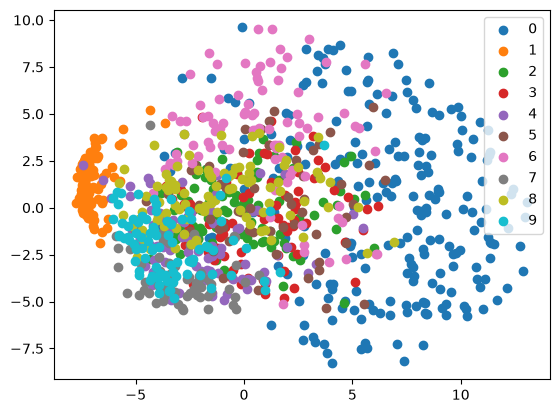

In [40]:
"PCA"

pca = PCA(n_components=2)
test_in_pca = pca.fit_transform(test_in)

for i in range(10):
    digit_mask = test_out == i
    plt.scatter(*test_in_pca[digit_mask].T, label=i)

plt.legend()
plt.show()